<a href="https://colab.research.google.com/github/fabriciothiengo/REATORES/blob/main/batelada_NI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**REAÇÃO EM BATELADA NÃO ISOTÉRMICA**

---

Seja a reação em fase gasosa 2A $→$3B, ocorrendo em um reator tanque em regime de tabelada, com 15% d inertes na alimentação. Utilizando os dados no código abaixo, qual o tempo e a temperatura para conversão de 70%?

<br>

O balanço de massa para uma reação em fase gasosa com volume variável é dado por:

<br>

$\frac{dN_A}{dt} = r_AV ⇒ \frac{d(C_AV)}{dt} = C_A\frac{dV}{dt}+V\frac{dC_a}{dt} = r_AV$

<br>

Ssabemos que $C_A=\frac{C_{A_0}(1-X)}{1+\epsilon X}$, $dC_A=-\frac{C_{A_0}(1+ϵ)}{(1+\epsilon X)^2}$, $V=V_0(1+ϵ X)$ e $dV=V_0 ϵ \ dX$.

<br>

Inserindo os termos no balanço, original, resulta em:

<br>

$\frac{dX}{dt}=k\frac{1-X}{1+ϵ X}$

<br>

Enquanto que o balanço de energia é dado por:

$\frac{dT}{dt}=\frac{-\Delta H |r_A|}{\rho C_p} - \frac{UA(T-T_c)}{V \rho C_p}$

Text(0, 0.5, 'X')

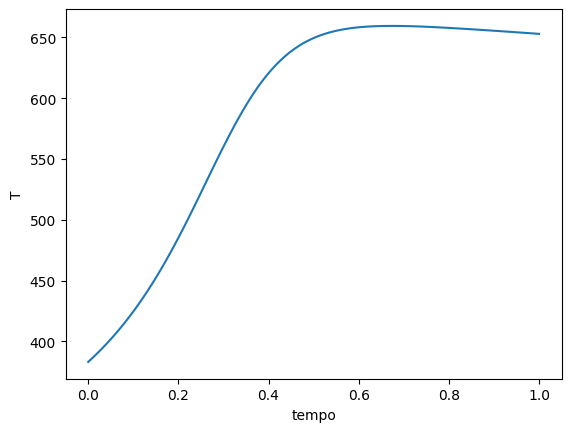

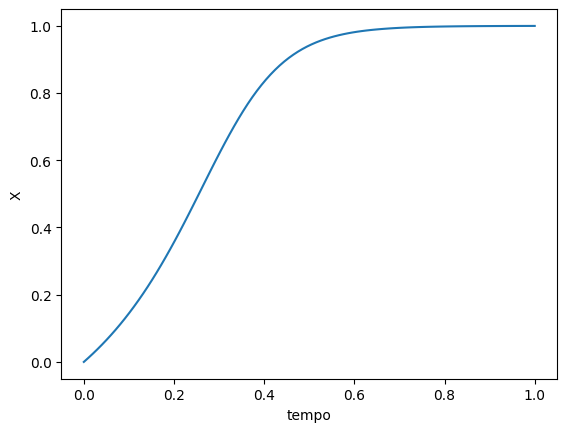

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def fun(t,S):
  T,X=S

  k1=3
  T1=450
  R=8.314
  T0=110+273
  V=4
  HA0=-3000e3
  HB0=-5000e3
  rho=1000
  CA0=1
  Tc=50+273
  Ea=20e3
  UA=1e4
  CpA=30
  CpB=10
  CpI=5
  yA0=0.85
  delta=(3-2)/2
  eps=yA0*delta

  k=k1*np.exp((-Ea/R)*((1/T)-(1/T1)))
  r_A=-k*CA0*(1-X)/(1+eps*X)
  Cp=CpA + (0.15/0.85)*CpI
  deltaH0=3*HB0-2*HA0
  deltaCp=3*CpB-2*CpA
  deltaH=deltaH0+deltaCp*(T-T0)
  dTdt=(-deltaH*abs(r_A))/(rho*Cp) - (UA*(T-Tc))/(V*rho*Cp)
  dXdt=k*(1-X)/(1+eps*X)

  return [dTdt,dXdt]

tempo=[0,1]
t=np.linspace(0,tempo[1],100)
y0=[110+273,0]
sol=solve_ivp(fun,tempo,y0,t_eval=t,method='Radau')

T=sol.y[0]
X=sol.y[1]

plt.figure(1)
plt.plot(sol.t,T)
plt.xlabel('tempo')
plt.ylabel('T')

plt.figure(2)
plt.plot(sol.t,X)
plt.xlabel('tempo')
plt.ylabel('X')
